# Load preTrained Models: Load and Evaluate

This notebook loads a pre-trained model and evaluates its predictions against training data. The workflow includes:

1. **Data Loading & Preprocessing**: Efficiently loads and preprocesses meteorological and ozone data from NetCDF files using a unified function
2. **Feature Selection**: Supports both daily and hourly frequency data with optional rasterized ozone channel
3. **Model Loading**: Loads the pre-trained model (with or without rasterized ozone features)
4. **Model Evaluation**: Evaluates model performance on the training dataset

The refactored code uses reusable functions for reproducibility and easier parameter tuning across different data frequencies and feature combinations.

# Imports

In [ ]:
#import matplotlib.pyplot as plt
import warnings
# turn off futurewarning from iris
warnings.filterwarnings("ignore", category=FutureWarning)
# turn off netcdf unknown variable warning from iris
warnings.filterwarnings("ignore", category=UserWarning, message=".*NetCDF variable.*")
# turn off IrisCfNonSpanningVarWarning
warnings.filterwarnings("ignore", category=UserWarning, message=".*IrisCfNonSpanningVarWarning.*")

import numpy as np

from matplotlib import pyplot as plt

import tensorflow as tf

import iris
iris.FUTURE.save_split_attrs = True

from model_lib.ml_utils import (
    is_running_in_notebook,
    load_pretrained_model,
    load_and_preprocess_training_data,
    parse_arguments,
)


# User parameters

In [2]:
# User parameters
# Note: Adjust these parameters as needed before running the notebook

training_frequency = "daily"  # Set to "hourly" or "daily"
with_rasterized_ozone = True  # Set to True to include rasterized ozone features
model_type = "MLP"  # Set to "MLP", "CNN", "CNN+LSTM", or "UNET"
ndays = 93 if training_frequency == "daily" else 30  # Number of days to load (93 for daily, 30 for hourly testing)
sequence_length = 3 if training_frequency == "daily" else 48   # Adjust as needed based on the model's expected input shape

# Apply CLI arguments only when run from shell/script (skip in Jupyter notebook)
if not is_running_in_notebook():
    args = parse_arguments()
    training_frequency = args.training_frequency
    with_rasterized_ozone = args.with_rasterized_ozone
    model_type = args.model_type
    ndays = args.ndays
    sequence_length = args.sequence_length

# Loading data and Trained Model

## Load xtrain and ytrain

In [3]:
# This section will load the training data based on the specified frequency and preprocess it for use with the pretrained model.
# The feature_selection_list defines which meteorological features to include as input to the model. The target_selection_list defines the target variable(s) for prediction, which is ozone concentration in this case.
# The load_and_preprocess_training_data function will handle loading the data from NetCDF files, filtering the cubes based on the selected features and targets, handling any NaN values, and normalizing the data for use with the model.
# After loading and preprocessing the data, the pretrained model will be loaded from the specified path, and its architecture will be summarized.
# Finally, the model will be evaluated on the training data to check its performance before proceeding to test data evaluation.
# Make sure to adjust the parameters at the top of this section as needed before running the notebook, especially if you want to test with a different frequency or include/exclude rasterized ozone features.

# Shared meteorological features
feature_selection_list = [
    "air_pressure_at_sea_level",
    "air_temperature",
    "relative_humidity",
    "x_wind",
    "y_wind",
    "precipitation_amount",
    "photolysis_rate_of_nitrogen_dioxide",
]

# Add rasterized ozone channel only when requested
if with_rasterized_ozone:
    feature_selection_list.append("rasterized_aqum_O3_at_AURN_sites")

target_selection_list = ["mass_concentration_of_ozone_in_air"]
pretrained_model_path = "Trained_models"

# Load and preprocess training data using the unified function
print("\n" + "="*80)
print("LOADING AND PREPROCESSING TRAINING DATA")
print("="*80)

data = load_and_preprocess_training_data(
    training_frequency=training_frequency,
    ndays=ndays,
    feature_selection_list=feature_selection_list,
    target_selection_list=target_selection_list,
    verbose=False  # Set to True for detailed processing messages
)

# Extract results from the returned dictionary
xtrain_data_normalised = data['xtrain_data_normalised']
ytrain_data_normalised = data['ytrain_data_normalised']
feature_names = data['feature_names']
ntime = data['ntime']
nlat = data['nlat']
nlon = data['nlon']
nfeature = data['nfeature']
nfeature_multiplier = data['nfeature_multiplier']
xtrain_cube_list_regridded = data['xtrain_cube_list_regridded']
ytrain_cube_list = data['ytrain_cube_list']
ntarget = len(target_selection_list)

print("\n" + "="*80)
print("DATA LOADING COMPLETE")
print("="*80)
print(f"X-train shape: {xtrain_data_normalised.shape}")
print(f"Y-train shape: {ytrain_data_normalised.shape}")
print(f"Features ({nfeature} + {nfeature_multiplier-1} mask channels): {feature_names}")



LOADING AND PREPROCESSING TRAINING DATA
Loading training data from: processed_data/Daily_snapshots
Number of days to load: 93
Feature selection list: ['air_pressure_at_sea_level', 'air_temperature', 'relative_humidity', 'x_wind', 'y_wind', 'precipitation_amount', 'photolysis_rate_of_nitrogen_dioxide', 'rasterized_aqum_O3_at_AURN_sites']
Target selection list: ['mass_concentration_of_ozone_in_air']
File multiplier based on frequency: 1
Expected number of files to load for Y-train: 93
Expected number of files to load for X-train: 93
Verbose mode is OFF: Detailed processing messages will not be printed.



/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)



DATA LOADING COMPLETE
X-train shape: (93, 112, 88, 16)
Y-train shape: (93, 112, 88, 1)
Features (8 + 1 mask channels): ['rasterized_aqum_O3_at_AURN_sites', 'air_pressure_at_sea_level', 'air_temperature', 'photolysis_rate_of_nitrogen_dioxide', 'precipitation_amount', 'relative_humidity', 'x_wind', 'y_wind']


# load pretrained ML model 1

In [4]:

# Now that the training data is loaded and preprocessed, we can proceed to load the pretrained model and evaluate its performance on the training data before moving on to test data evaluation.
# The pretrained model will be loaded based on the specified parameters, and its architecture will be summarized to confirm that it has been loaded correctly.
# After loading the model, we will evaluate its performance on the training data to check for any issues before proceeding to test data evaluation.
# Make sure to adjust the parameters at the top of this section as needed before running the notebook, especially if you want to test with a different frequency or include/exclude rasterized ozone features.
# Note: The evaluation on training data is just a sanity check to ensure the model is working correctly with the loaded data. The main evaluation will be done on the test data in the next section.

# Load the pretrained model
print("\n" + "="*80)
print("LOADING PRETRAINED MODEL")
print("="*80)

if training_frequency not in {"daily", "hourly"}:
    raise ValueError("training_frequency must be 'daily' or 'hourly'")

# Support either spelling if present in the notebook
use_rasterized_ozone = globals().get(
    "with_rasterized_ozone",
    globals().get("with_rasterised_ozone", False)
)

model = load_pretrained_model(
    model_path=pretrained_model_path,
    model_type=model_type,
    frequency=training_frequency,
    with_rasterized_ozone=use_rasterized_ozone
)

model.summary() 


LOADING PRETRAINED MODEL


2026-03-27 18:02:40.461232: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 968884224 exceeds 10% of free system memory.
2026-03-27 18:02:41.528064: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 968884224 exceeds 10% of free system memory.
2026-03-27 18:02:42.084643: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 968884224 exceeds 10% of free system memory.
2026-03-27 18:02:43.136716: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 968884224 exceeds 10% of free system memory.
2026-03-27 18:02:43.346730: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 968884224 exceeds 10% of free system memory.


Successfully loaded model from Trained_models/MLP_model_daily_with_rasterized_o3.keras


Model: "mlp_ozone_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ meteo_sequence (InputLayer)     │ (None, 3, 112, 88, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 473088)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │   242,221,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9856)           │     2,532,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ozone_forecast (Reshape)        │ (None, 112, 88, 1)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 734,663,810 (2.74 GB)

 Trainable params: 244,887,424 (934.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 489,774,850 (1.82 GB)

# Evaluation

In [5]:
print("\n" + "="*80)
print("EVALUATING PRETRAINED MODEL ON TRAINING DATA")
print("="*80)

# split data into sequences for ConvLSTM input

n_samples = ntime - sequence_length + 1
xtrain_sequences = np.array([xtrain_data_normalised[i:i+sequence_length] for i in range(n_samples)], dtype=np.float32)
ytrain_sequences = np.array([ytrain_data_normalised[i+sequence_length-1] for i in range(n_samples)], dtype=np.float32)

print(f"X-train sequences shape: {xtrain_sequences.shape}")
print(f"Y-train sequences shape: {ytrain_sequences.shape}")
print(f"Model input shape: {model.input_shape}")
print(f"Model output shape: {model.output_shape}")

# Ensure data is convertible to tensors and evaluate the model
try:
	# Convert to TensorFlow tensors to catch any shape issues early
	xtrain_tensor = tf.convert_to_tensor(xtrain_sequences, dtype=tf.float32)
	ytrain_tensor = tf.convert_to_tensor(ytrain_sequences, dtype=tf.float32)
	
	print(f"X-train tensor shape: {xtrain_tensor.shape}")
	print(f"Y-train tensor shape: {ytrain_tensor.shape}")
	
	# Verify shapes match model expectations
	if xtrain_tensor.shape[1:] != model.input_shape[1:]:
		print(f"Warning: Input shape mismatch!")
		print(f"Expected: {model.input_shape}")
		print(f"Got: {tuple([None] + list(xtrain_tensor.shape[1:]))}")
	
	# Evaluate the model
	train_loss = model.evaluate(xtrain_tensor, ytrain_tensor, verbose=1)
	print(f"\nTraining Loss: {train_loss}")
except (ValueError, tf.errors.InvalidArgumentError) as e:
	print(f"Error during evaluation: {e}")
	print("Checking model and data compatibility...")
	print(f"Expected input shape: {model.input_shape}")
	print(f"Actual input shape: {tuple([None] + list(xtrain_sequences.shape[1:]))}")
	print(f"\nDebugging info:")
	print(f"  ntime: {ntime}")
	print(f"  sequence_length: {sequence_length}")
	print(f"  n_samples: {n_samples}")
	print(f"  nfeature * nfeature_multiplier: {nfeature * nfeature_multiplier}")
	raise




EVALUATING PRETRAINED MODEL ON TRAINING DATA
X-train sequences shape: (91, 3, 112, 88, 16)
Y-train sequences shape: (91, 112, 88, 1)
Model input shape: (None, 3, 112, 88, 16)
Model output shape: (None, 112, 88, 1)
X-train tensor shape: (91, 3, 112, 88, 16)
Y-train tensor shape: (91, 112, 88, 1)
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 265ms/step - loss: 0.0081 - mae: 0.0723

Training Loss: [0.008135735057294369, 0.07234423607587814]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step

Predictions shape: (5, 112, 88, 1)
True values shape: (5, 112, 88, 1)
Residual shape: (5, 112, 88, 1)
Relative error shape: (5, 112, 88, 1)


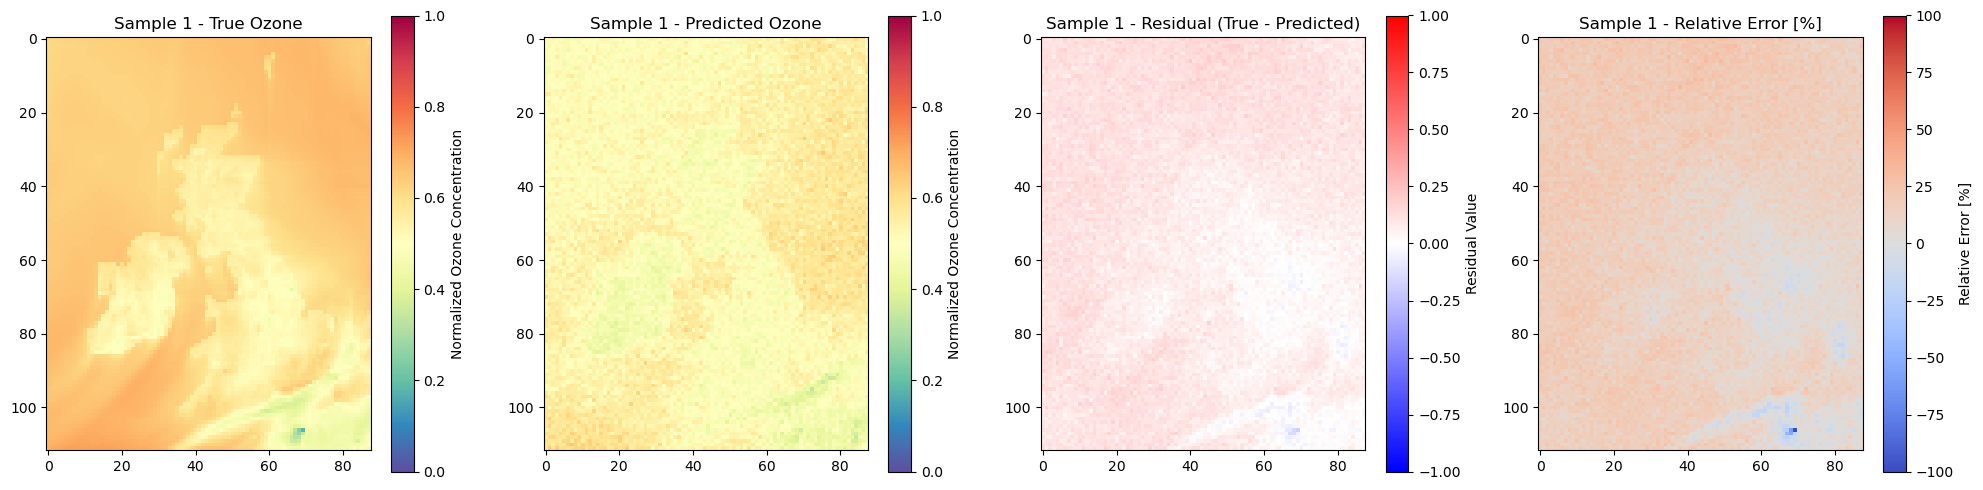

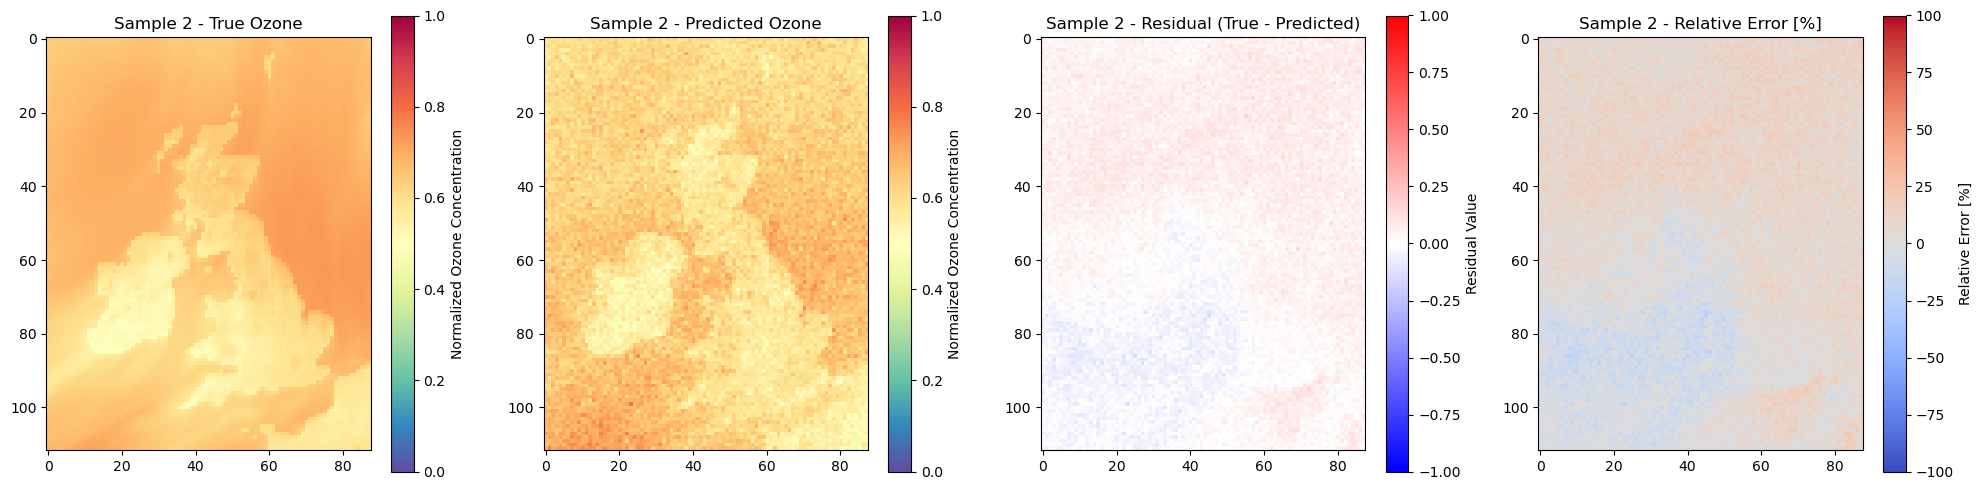

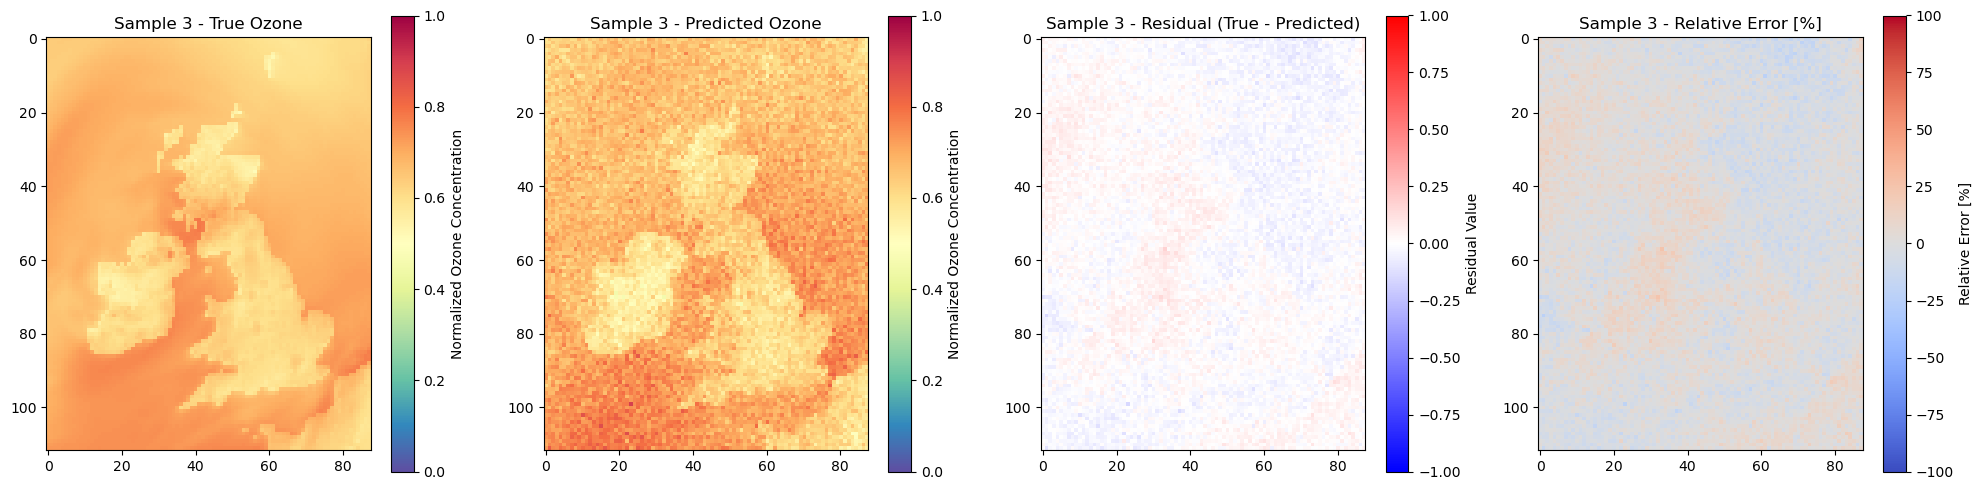

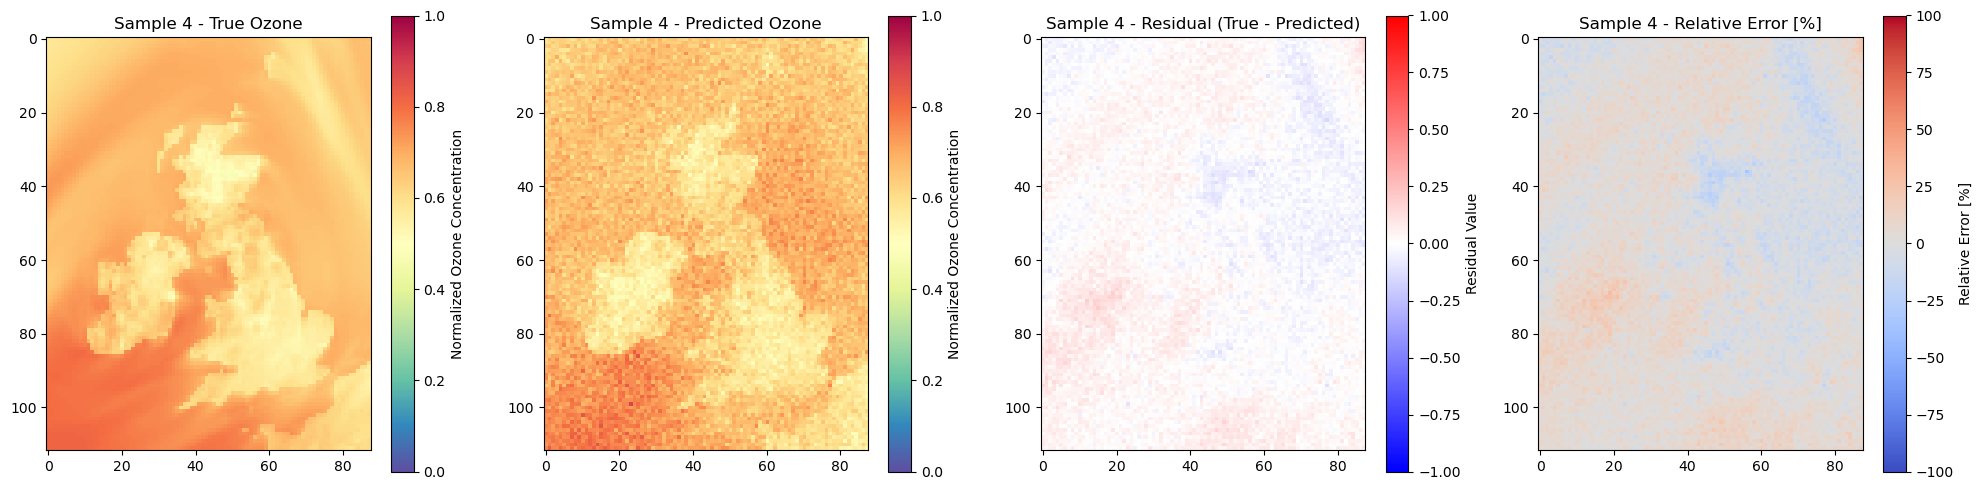

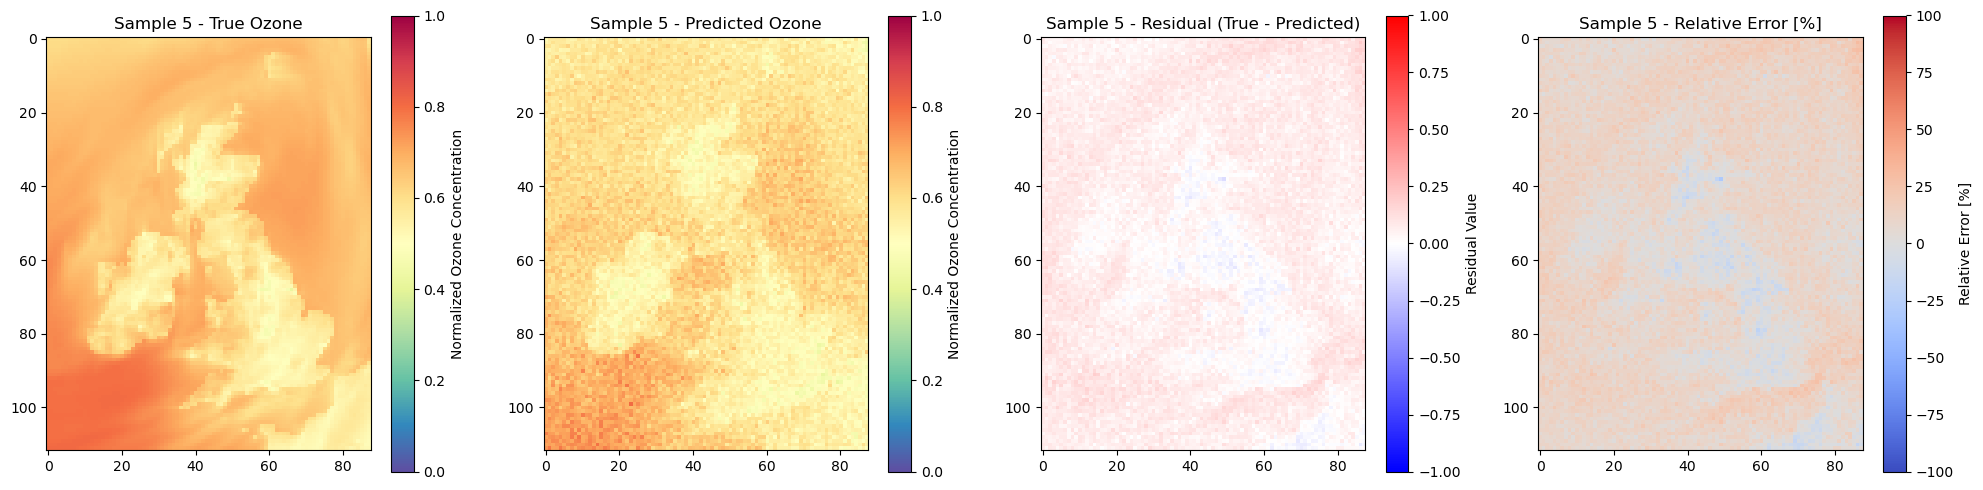

In [ ]:
# If we're in a notebook, we can show detailed plots of predictions vs true values for the first few samples
if is_running_in_notebook():
    # PLOT PREDICTION for 5 steps against true values for the training data
    pred = model.predict(xtrain_tensor[:5])
    print(f"\nPredictions shape: {pred.shape}")
    print(f"True values shape: {ytrain_tensor[:5].shape}")
    residual = ytrain_tensor[:5] - pred
    print(f"Residual shape: {residual.shape}")

    # Relative error (residual / true value), guarded against divide-by-zero
    relative_error = tf.where(
        ytrain_tensor[:5] != 0,
        100 * (residual / ytrain_tensor[:5]),
        tf.zeros_like(residual),
    )
    print(f"Relative error shape: {relative_error.shape}")

    # Plot true vs predicted vs residual vs relative error for the first 5 samples
    for i in range(5):
        plt.figure(figsize=(20, 5))

        plt.subplot(1, 4, 1)
        plt.title(f"Sample {i + 1} - True Ozone")
        plt.imshow(ytrain_tensor[i, ::-1, :, 0], vmin=0, vmax=1, cmap='Spectral_r')
        plt.colorbar(label="Normalized Ozone Concentration")

        plt.subplot(1, 4, 2)
        plt.title(f"Sample {i + 1} - Predicted Ozone")
        plt.imshow(pred[i, ::-1, :, 0], vmin=0, vmax=1, cmap='Spectral_r')
        plt.colorbar(label="Normalized Ozone Concentration")

        plt.subplot(1, 4, 3)
        plt.title(f"Sample {i + 1} - Residual (True - Predicted)")
        plt.imshow(residual[i, ::-1, :, 0], vmin=-1, vmax=1, cmap='bwr')
        plt.colorbar(label="Residual Value")

        plt.subplot(1, 4, 4)
        plt.title(f"Sample {i + 1} - Relative Error [%]")
        plt.imshow(relative_error[i, ::-1, :, 0], vmin=-100, vmax=100, cmap='coolwarm')
        plt.colorbar(label="Relative Error [%]")

        plt.tight_layout()
        plt.show()